# Feature Fusion - Stanford Dogs

Purpose: demonstrates feature fusion approach that combines embeddings from ResNet50 and EfficientNetB0.

**Architecture:**
- ResNet50 backbone -> Global pooling -> Batch Norm -> 1024-dim embedding
- EfficientNetB0 backbone -> Global pooling -> Batch Norm -> 1024-dim embedding
- Concatenate embeddings -> Dense(256) -> Batch Norm -> Dropout -> Classifier

**Training strategy:**
- Both backbones are **frozen** (using pretrained ImageNet weights)
- Only the fusion head (concat → dense → classifier) is trained
- This learns how to optimally combine features from both architectures

The contents of this notebook:

- [Feature Fusion](#feature-fusion)
  - [1. Imports & Setup](#1-imports--setup)
  - [2. Load Raw Dataset](#2-load-raw-dataset)
  - [3. Preprocess Dataset for BOTH Models](#3-preprocess-dataset-for-both-models)
  - [4. Build Feature Fusion Model](#4-build-feature-fusion-model)
  - [5. Compile Model](#5-compile-model)
  - [6. Setup Callbacks](#6-setup-callbacks)
  - [7. Train Model](#7-train-model)
  - [8. Evaluate Model](#8-evaluate-model)
  - [9. Plot & Save Training History](#9-plot--save-training-history)
  - [10. Evaluations](#10-evaluations)
  - [11. Save Model Architecture Diagram](#11-save-model-architecture-diagram)
  - [12. Summary](#12-summary)

## Feature Fusion

### 1. Imports & Setup

In [1]:
import sys
sys.path.insert(0, "..")

import os
import json
import yaml
import numpy as np
import tensorflow as tf
from tensorflow import keras


cfg = yaml.safe_load(open("../config/default.yaml"))

tf.random.set_seed(cfg["seed"])
np.random.seed(cfg["seed"])

print(f"TensorFlow version: {tf.__version__}")
print(f"Random seed: {cfg['seed']}")

TensorFlow version: 2.20.0
Random seed: 42


### 2. Load Raw Dataset

In [3]:
from src.data.dataset import load_stanford_dogs, get_num_classes

(train_ds, test_ds), ds_info, class_names = load_stanford_dogs(as_supervised=True)
num_classes = get_num_classes(ds_info)

print(f"Dataset: {ds_info.name}")
print(f"Train samples: {ds_info.splits['train'].num_examples}")
print(f"Test samples: {ds_info.splits['test'].num_examples}")
print(f"Number of classes: {num_classes}")

Dataset: stanford_dogs
Train samples: 12000
Test samples: 8580
Number of classes: 120


### 3. Preprocess Dataset for BOTH Models

The fusion model needs preprocessing for **both** ResNet50 and EfficientNetB0.

The preprocessing pipeline returns a **dict** with two keys:
```python
{
    "resnet50": tensor_normalized_for_resnet,
    "efficientnetb0": tensor_normalized_for_efficientnet
}
```

This matches the fusion model's input layer names.

The preprocessing pipeline contains:
1. Resize images to 224×224
2. Augment training images (flip, rotate, zoom, translate, contrast)
3. Normalize using ResNet50's and EfficientNet's preprocessing functions for ResNet50 and EfficientNetB0, respectively

In [4]:
from src.data.preprocessing import preprocess_dataset, inspect_dataset

train_prep, val_prep = preprocess_dataset(
    train_ds=train_ds,
    valid_ds=test_ds,
    model_names=["resnet50", "efficientnetb0"], 
    img_size=cfg["dataset"]["img_size"],
    batch_size=cfg["dataset"]["batch_size"]
)

# Inspect preprocessed datasets
inspect_dataset(train_prep, val_prep, class_names, model_names=["resnet50", "efficientnetb0"])

Training batches  : 375
Validation batches: 269

Training split
----------------------------------------
[input_resnet50]
    shape : (32, 224, 224, 3)
    dtype : <dtype: 'float32'>
    range : [-123.68, 151.06]
[input_efficientnetb0]
    shape : (32, 224, 224, 3)
    dtype : <dtype: 'float32'>
    range : [0.00, 255.00]
[labels]
    shape : (32,)

Validation split
----------------------------------------
[input_resnet50]
    shape : (32, 224, 224, 3)
    dtype : <dtype: 'float32'>
    range : [-123.68, 151.06]
[input_efficientnetb0]
    shape : (32, 224, 224, 3)
    dtype : <dtype: 'float32'>
    range : [0.00, 255.00]
[labels]
    shape : (32,)

Classes          : 120
Sample names     : ['chihuahua', 'japanese_spaniel', 'maltese_dog', 'pekinese', 'shih-tzu']


### 4. Build Feature Fusion Model



In [7]:
from src.models.fusion import build_fusion_model, embedding_dimensions
from src.models.resnet50 import count_trainable_params
keras.backend.clear_session()

model = build_fusion_model(
    num_classes=num_classes,
    img_size=cfg["dataset"]["img_size"],
    freeze_backbones=cfg["models"]["fusion"]["freeze_backbones"],
    dense_units=cfg["models"]["fusion"]["dense_units"],
    # dropout=cfg["models"]["fusion"]["dropout"],
)

# embedding dimensions
embedding_dims = embedding_dimensions(model)
print(f"\nEmbedding dimensions:")
for name, dim in embedding_dims.items():
    print(f"  {name}: {dim}")
print(f"  Total (concatenated): {sum(embedding_dims.values())}")

# Count parameters
# trainable, non_trainable = count_trainable_params(model)
# print(f"\nTrainable parameters: {trainable:,}")
# print(f"Non-trainable parameters: {non_trainable:,}")
# print(f"Total parameters: {trainable + non_trainable:,}")

model.summary()



Embedding dimensions:
  resnet50: 1024
  efficientnetb0: 1024
  Total (concatenated): 2048


Model: "FeatureFusion_ResNet50_EfficientNetB0"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_resnet50      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_efficientnet… │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ input_resnet50[0… │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb0      │ (None, 7, 7,      │  4,049,571 │ input_efficientn… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet_pool         │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ effnet_pool         │ (None, 1280)      │          0 │ efficientnetb0[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet_bn           │ (None, 2048)      │      8,192 │ resnet_pool[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ effnet_bn           │ (None, 1280)      │      5,120 │ effnet_pool[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet_dense        │ (None, 1024)      │  2,098,176 │ resnet_bn[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ effnet_dense        │ (None, 1024)      │  1,311,744 │ effnet_bn[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_concat       │ (None, 2048)      │          0 │ resnet_dense[0][… │
│ (Concatenate)       │                   │            │ effnet_dense[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_dense        │ (None, 256)       │    524,544 │ fusion_concat[0]… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_bn           │ (None, 256)       │      1,024 │ fusion_dense[0][… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_dropout      │ (None, 256)       │          0 │ fusion_bn[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ classifier (Dense)  │ (None, 120)       │     30,840 │ fusion_dropout[0… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 31,616,923 (120.61 MB)

 Trainable params: 3,972,472 (15.15 MB)

 Non-trainable params: 27,644,451 (105.46 MB)

### 5. Compile Model

In [5]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=cfg["training"]["frozen"]["initial_lr"]),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        "accuracy",
        keras.metrics.SparseTopKCategoricalAccuracy(k=5, name="top_5_accuracy"),
    ],
)


### 6. Setup Callbacks


In [6]:
from src.training.callbacks import create_callbacks
os.makedirs(cfg["paths"]["checkpoints"], exist_ok=True)

callbacks = create_callbacks(
    checkpoint_path=os.path.join(cfg["paths"]["checkpoints"], "fusion_frozen.keras"),
    monitor="val_accuracy",
    mode="max",
    early_stop_patience=cfg["training"]["frozen"]["early_stop_patience"],
    reduce_lr_patience=cfg["training"]["frozen"]["reduce_lr_patience"],
    reduce_lr_factor=cfg["training"]["frozen"]["reduce_lr_factor"],
)

### 7. Train Model

In [7]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=cfg["training"]["frozen"]["initial_lr_fusion"]),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        "accuracy",
        keras.metrics.SparseTopKCategoricalAccuracy(k=5, name="top_5_accuracy"),
    ],
)

print("Learning rate:", model.optimizer.learning_rate.numpy())

Learning rate: 1e-04


In [8]:
# set up callbacks
from src.training.callbacks import create_callbacks
os.makedirs(cfg["paths"]["checkpoints"], exist_ok=True)

callbacks = create_callbacks(
    checkpoint_path=os.path.join(cfg["paths"]["checkpoints"], "fusion_frozen.keras"),
    monitor="val_accuracy",
    mode="max",
    early_stop_patience=cfg["training"]["frozen"]["early_stop_patience"],
    reduce_lr_patience=cfg["training"]["frozen"]["reduce_lr_patience"],
    reduce_lr_factor=cfg["training"]["frozen"]["reduce_lr_factor"],
)

In [9]:
# Train model
history = model.fit(
    train_prep,
    validation_data=val_prep,
    epochs=cfg["training"]["frozen"]["epochs_fusion"],
    callbacks=callbacks,
)

Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.1006 - loss: 4.5788 - top_5_accuracy: 0.2661
Epoch 1: val_accuracy improved from None to 0.69149, saving model to ../artefacts/checkpoints\fusion_frozen.keras

Epoch 1: finished saving model to ../artefacts/checkpoints\fusion_frozen.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 2498s 7s/step - accuracy: 0.2001 - loss: 3.7055 - top_5_accuracy: 0.4338 - val_accuracy: 0.6915 - val_loss: 1.2600 - val_top_5_accuracy: 0.9332 - learning_rate: 1.0000e-04
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.4403 - loss: 2.2678 - top_5_accuracy: 0.7415
Epoch 2: val_accuracy improved from 0.69149 to 0.77214, saving model to ../artefacts/checkpoints\fusion_frozen.keras

Epoch 2: finished saving model to ../artefacts/checkpoints\fusion_frozen.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 2390s 6s/step - accuracy: 0.4700 - loss: 2.1286 - top_5_accuracy: 0.7659 - val_accuracy: 0.7721 - val_loss: 0.8089 - val_top_5_accuracy: 0.9653 - learning_rate

### 8. Evaluate Model

In [10]:
# evaluate model
from src.evaluation.metrics import evaluate_model
from src.evaluation.viz import plot_training_history

print("Feature Fusion Model Evaluation:")
results = evaluate_model(model, val_prep, verbose=1)
print(f"\nLoss: {results['loss']:.4f}")
print(f"Accuracy: {results['accuracy']:.4f}")
print(f"Top-5 Accuracy: {results['top_5_accuracy']:.4f}")

Feature Fusion Model Evaluation:
269/269 ━━━━━━━━━━━━━━━━━━━━ 970s 4s/step - accuracy: 0.8408 - loss: 0.5326 - top_5_accuracy: 0.9819

Loss: 0.5326
Accuracy: 0.8408
Top-5 Accuracy: 0.9819


### 9. Plot & Save Training History

Saved plot to ../artefacts/evaluations\fusion_history.png


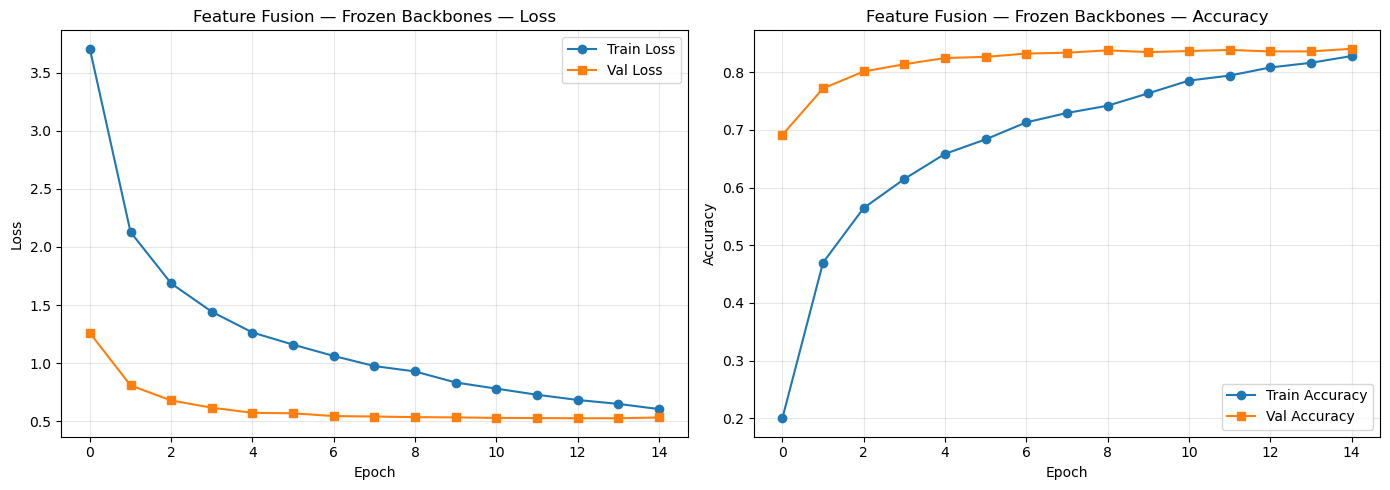

In [11]:
# plot training history
os.makedirs(cfg["paths"]["evaluations"], exist_ok=True)
plot_training_history(
    history.history,
    title="Feature Fusion — Frozen Backbones",
    save_path=os.path.join(cfg["paths"]["evaluations"], "fusion_history.png"),
)

In [12]:
# Save history as JSON
os.makedirs(cfg["paths"]["histories"], exist_ok=True)
with open(os.path.join(cfg["paths"]["histories"], "fusion_frozen.json"), "w") as f:
    json.dump(history.history, f, indent=2)

print("Training history saved.")

Training history saved.


### 10. Evaluations

The trained model is evaluated and confusion matrix, per-class metrics and top confused pairs are visualized.

In [13]:
# predictions
from src.evaluation.metrics import get_predictions, compute_confusion_matrix

y_pred, y_true = get_predictions(model, val_prep)
print(f"Predictions shape: {y_pred.shape}")
print(f"True labels shape: {y_true.shape}")

Predictions shape: (8580,)
True labels shape: (8580,)


Saved plot to ../artefacts/evaluations\fusion_confusion_matrix.png


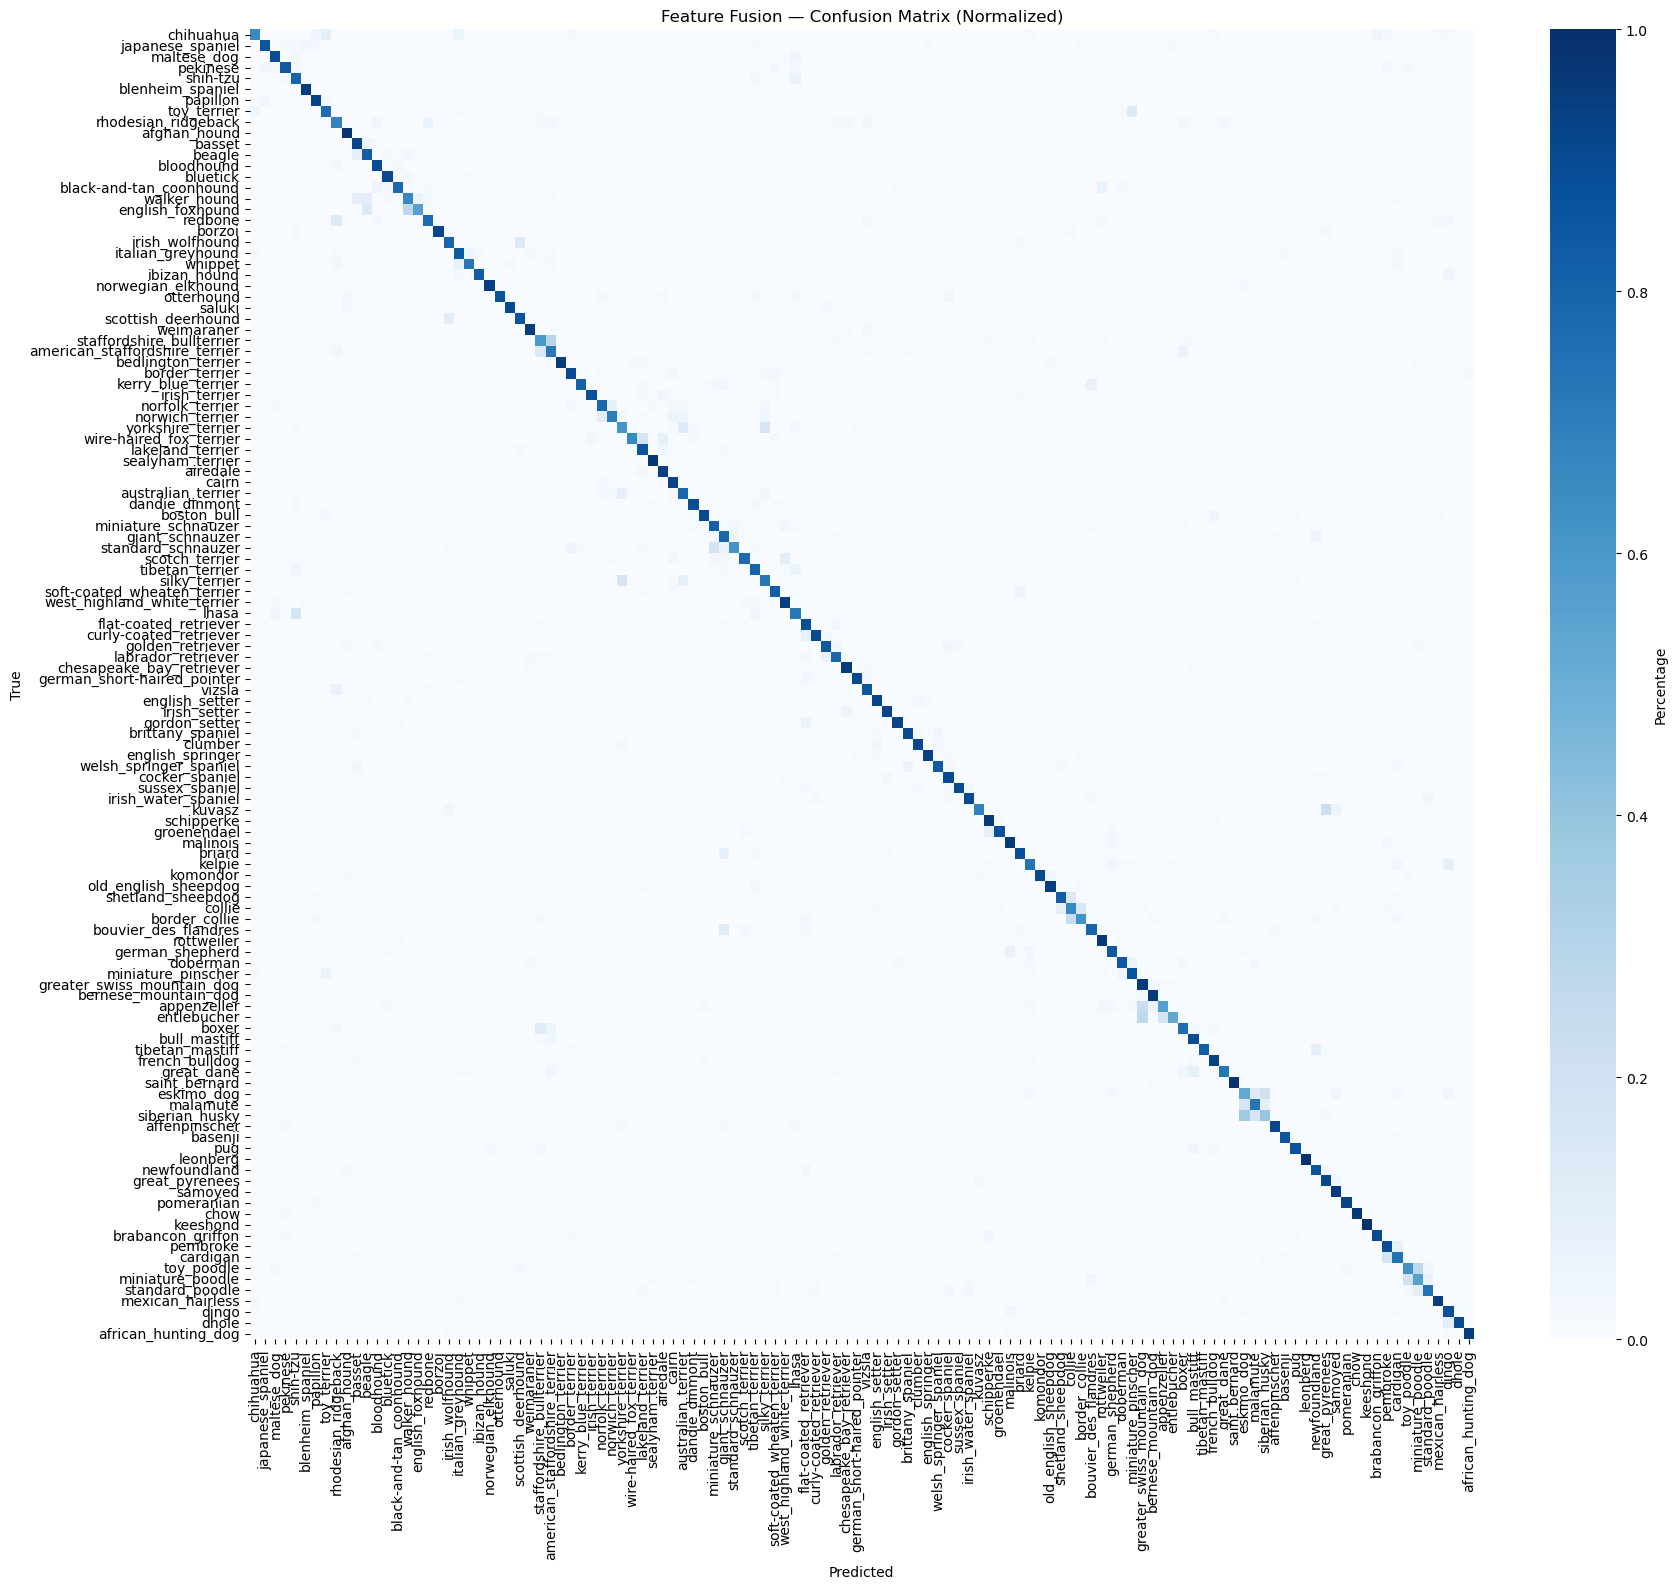

In [14]:
# confusion matrix
from src.evaluation.viz import plot_confusion_matrix

cm = compute_confusion_matrix(y_true, y_pred, num_classes)

plot_confusion_matrix(
    cm,
    class_names,
    normalize=True,
    title="Feature Fusion — Confusion Matrix (Normalized)",
    figsize=(18, 16),
    save_path=os.path.join(cfg["paths"]["evaluations"], "fusion_confusion_matrix.png"),
)

Top 10 Most Confused Pairs:
 1.                 siberian_husky → eskimo_dog                     :  34 errors
 2.                    entlebucher → greater_swiss_mountain_dog     :  28 errors
 3.                    entlebucher → appenzeller                    :  18 errors
 4.               english_foxhound → walker_hound                   :  16 errors
 5.                irish_wolfhound → scottish_deerhound             :  16 errors
 6.      staffordshire_bullterrier → american_staffordshire_terrier :  16 errors
 7.                 siberian_husky → malamute                       :  16 errors
 8.                          lhasa → shih-tzu                       :  15 errors
 9.             scottish_deerhound → irish_wolfhound                :  14 errors
10.                  silky_terrier → yorkshire_terrier              :  14 errors
Saved plot to ../artefacts/evaluations\fusion_confused_pairs.png


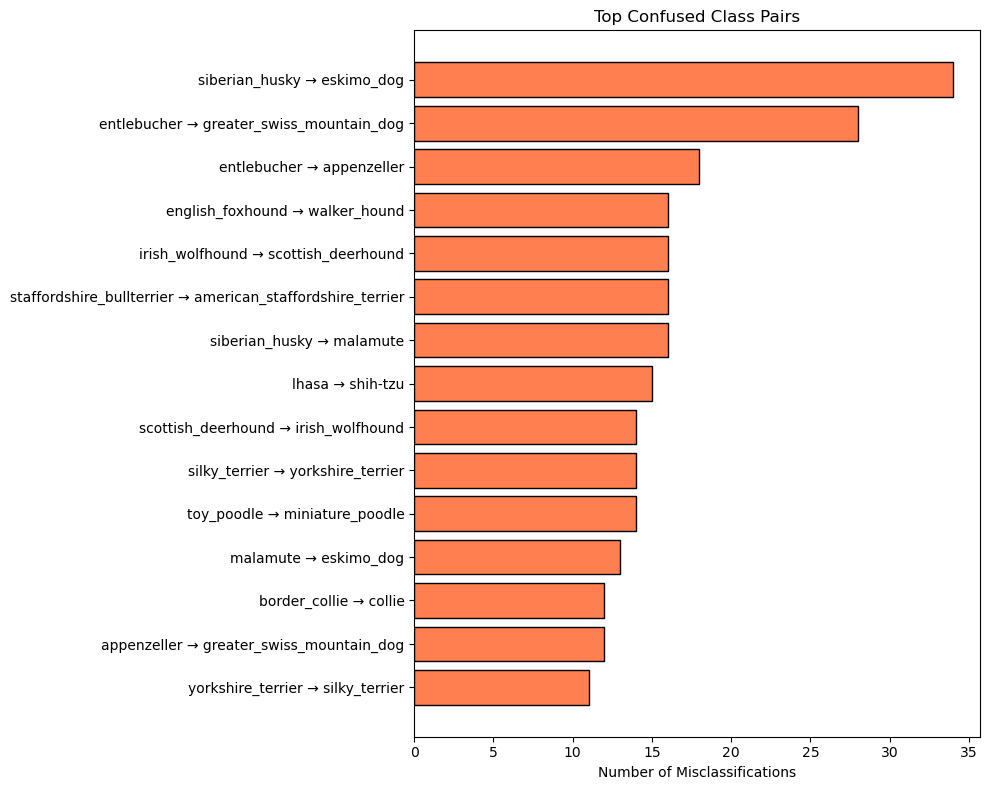

In [15]:
# plot confused pairs
from src.evaluation.metrics import top_confused_pairs
from src.evaluation.viz import plot_top_k_confusion_pairs

confused_pairs = top_confused_pairs(cm, class_names, top_k=15)

# Print top 10
print("Top 10 Most Confused Pairs:")
for i, (true_cls, pred_cls, count) in enumerate(confused_pairs[:10], 1):
    print(f"{i:2d}. {true_cls:>30s} → {pred_cls:<30s} : {count:3d} errors")

# Plot
plot_top_k_confusion_pairs(
    confused_pairs,
    top_k=15,
    save_path=os.path.join(cfg["paths"]["evaluations"], "fusion_confused_pairs.png"),
)

10 Worst Performing Classes (by F1):
                    eskimo_dog  F1=0.409  Precision=0.338  Recall=0.520
                siberian_husky  F1=0.486  Precision=0.643  Recall=0.391
              miniature_poodle  F1=0.569  Precision=0.574  Recall=0.564
                   appenzeller  F1=0.580  Precision=0.592  Recall=0.569
     staffordshire_bullterrier  F1=0.584  Precision=0.569  Recall=0.600
             yorkshire_terrier  F1=0.605  Precision=0.600  Recall=0.609
                  walker_hound  F1=0.619  Precision=0.583  Recall=0.660
                        collie  F1=0.631  Precision=0.603  Recall=0.660
                    toy_poodle  F1=0.640  Precision=0.653  Recall=0.627
american_staffordshire_terrier  F1=0.643  Precision=0.582  Recall=0.719
Saved plot to ../artefacts/evaluations\fusion_worst_classes.png


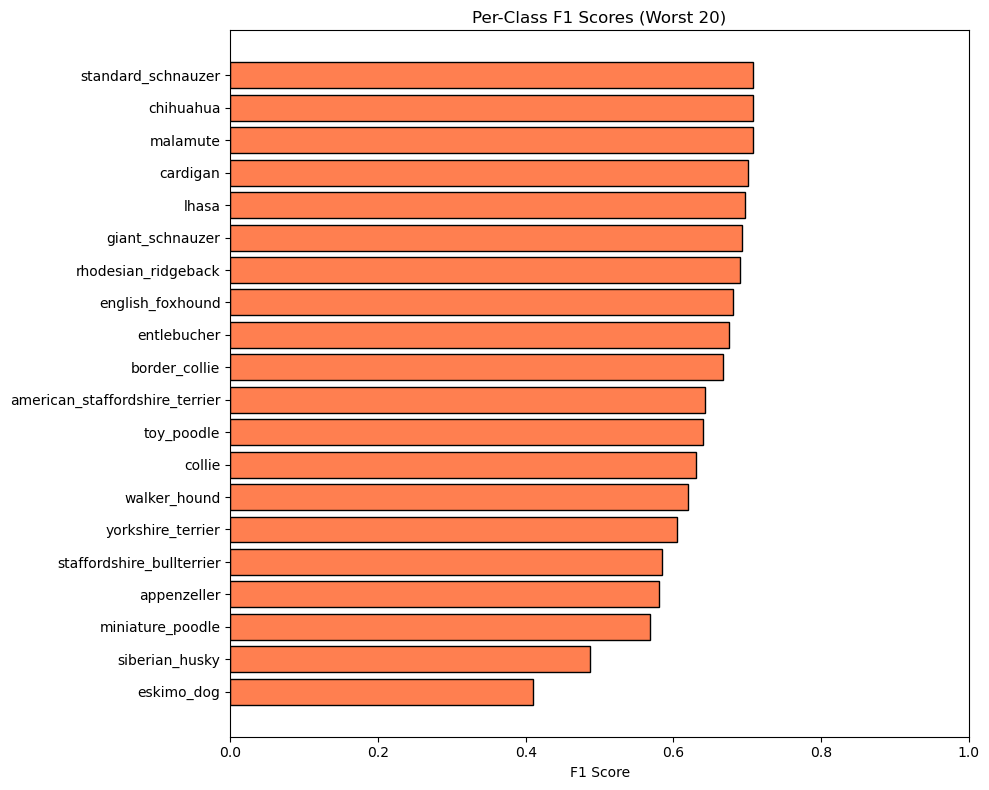

In [16]:
# per class metrics
from src.evaluation.metrics import get_per_class_metrics
from src.evaluation.viz import plot_per_class_f1

per_class_metrics = get_per_class_metrics(y_true, y_pred, class_names)
print("10 Worst Performing Classes (by F1):")
worst_10 = list(per_class_metrics.items())[:10]
for name, scores in worst_10:
    print(f"{name:>30s}  F1={scores['f1']:.3f}  Precision={scores['precision']:.3f}  Recall={scores['recall']:.3f}")

plot_per_class_f1(
    per_class_metrics,
    top_n=20,
    worst=True,
    save_path=os.path.join(cfg["paths"]["evaluations"], "fusion_worst_classes.png"),
)

### 11. Save Model Architecture Diagram

In [18]:
from tensorflow.keras.utils import plot_model
os.makedirs(cfg["paths"]["architecture_diagrams"], exist_ok=True)


plot_model(
    model,
    to_file=os.path.join(cfg["paths"]["architecture_diagrams"], "fusion_architecture.png"),
    show_shapes=True,
    show_layer_names=True,
    rankdir="TB",
    expand_nested=False,
    dpi=150,
)

print("Model architecture diagram saved.")

Model architecture diagram saved.


### 12. Summary

**Fusion Model Results:**
- Val Accuracy: 84.08%
- Val Top-5 Accuracy: 98.19%
- Val Loss: 0.53256
- Trainable Parameters: 3,969,912 

**Key Observations:**
- Fusion model combines complementary features from both architectures
- Training only the fusion head is fast (backbones frozen)
- Compare performance against individual models in notebook 05
